## Interactive Clustering Tool

### Motivation

This project builds an end-to-end clustering pipeline combining exploratory analysis,
hierarchical clustering, K-means segmentation and PCA-based visualisation.

### Usage

The notebook can be used in two modes:

- **Interactive mode** — apply the workflow to any CSV stored in `../data`

      USE_DEFAULTS = False

- **Default demo mode** — run the full workflow on the built-in customer segmentation dataset

      USE_DEFAULTS = True

The notebook expects the repository structure:

```text
clustering-segmentation-workbench/
├── data/
└── notebooks/
    └── cluster-pipeline.ipynb
```

In [12]:
from pathlib import Path

# ---------------------------------------------------------------------
# Notebook configuration
# ---------------------------------------------------------------------
USE_DEFAULTS = True

DATA_DIR = Path("../data")

DEFAULT_FILE = "customer-segmentation-synthetic.csv"
DEFAULT_THRESH = 0.50
DEFAULT_BRANCHES = 4
DEFAULT_CLUSTERS = 3
DEFAULT_VARIANCE = 0.80

RANDOM_STATE = 42
DENDROGRAM_SAMPLE_LIMIT = 5000

### Import packages and set up

In [13]:
import warnings
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import ipywidgets as widgets
from IPython.display import display, clear_output

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline

warnings.simplefilter(action="ignore", category=FutureWarning)

CMAP = plt.cm.rainbow
PALETTE = [
    "lime", "red", "blue", "gold", "orange",
    "green", "grey", "blueviolet", "fuchsia",
    "turquoise", "yellow"
]

FONT = 14
scaler = StandardScaler()
sns.set_style("ticks")


def style_axes(ax, font_size=FONT, grid=False):
    """Apply the notebook's scientific plotting style consistently."""
    plt.setp(ax.spines.values(), linewidth=2)

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        pad=7,
        length=6,
        width=1.5,
        labelsize=font_size,
        right=True,
        top=True,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=3,
        width=1.2,
        right=True,
        top=True,
    )

    ax.minorticks_on()
    ax.grid(grid, alpha=0.3 if grid else 1.0)

### Pre-processing and exploratory analysis

- Select a dataset
- Retain numeric features
- Remove rows containing missing numeric values
- Calculate the correlation matrix
- List feature pairs above a selected absolute Pearson correlation threshold

-------------------------------------------------------------------------------------
Running in DEFAULT MODE — processing 'customer-segmentation-synthetic.csv' with threshold 0.5
-------------------------------------------------------------------------------------

Business Problem

Can customer populations be segmented into meaningful behavioural groups to support targeting, pricing, and engagement strategies?

-------------------------------------------------------
Strongest correlations — pairs with |Pearson r| > 0.50
-------------------------------------------------------
Education  Income        0.816575
Income     Occupation    0.731943
Education  Occupation    0.637108
Age        Income        0.599483
           Education     0.559392


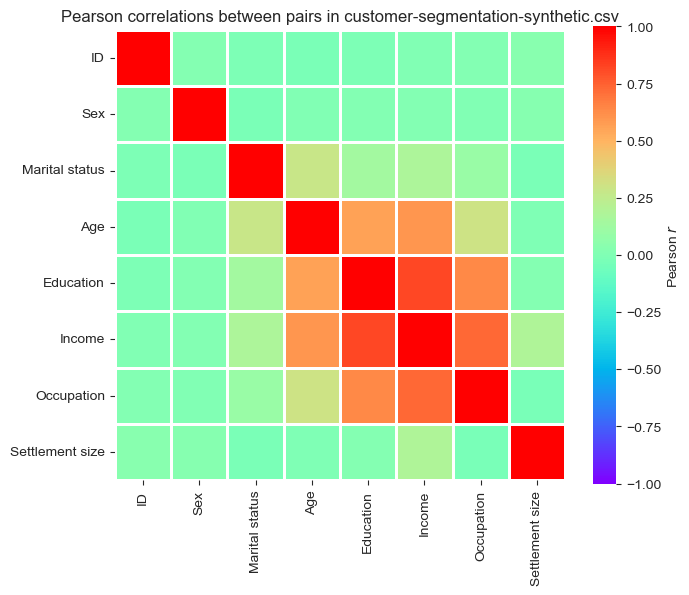

In [14]:
csv_files = sorted(path.name for path in DATA_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {DATA_DIR.resolve()}. "
        "Add at least one CSV to the repository data/ directory."
    )

if DEFAULT_FILE not in csv_files:
    DEFAULT_FILE = csv_files[0]

dd_file = widgets.Dropdown(
    options=csv_files,
    description="Select file:",
    value=DEFAULT_FILE,
    layout={"width": "40%"},
)

sl_thresh = widgets.FloatSlider(
    value=DEFAULT_THRESH,
    min=0.50,
    max=1.00,
    step=0.05,
    description="Correlation threshold:",
    layout={"width": "40%"},
    style={"description_width": "initial"},
    readout_format=".2f",
)


def read(filename=None):
    """Read a CSV from ../data and return complete numeric rows."""
    filename = filename or dd_file.value
    path = DATA_DIR / filename

    data = pd.read_csv(path)

    initial_rows = len(data)
    data = data.select_dtypes(include=np.number).copy()
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    dropped_rows = initial_rows - len(data)

    if data.shape[1] < 2:
        raise ValueError("At least two usable numeric columns are required.")

    if dropped_rows > 0:
        print(
            f"Warning: Dropped {dropped_rows:,} rows containing missing/non-finite "
            f"numeric values (remaining rows: {len(data):,})"
        )

    return data


def correlation_analysis(filename, threshold):
    data = read(filename)
    corr = data.corr(numeric_only=True)

    pairs = corr.abs().unstack()
    mask = (
        pairs.index.get_level_values(0)
        < pairs.index.get_level_values(1)
    ) & (pairs > threshold)

    top_corr = pairs[mask].sort_values(ascending=False)

    if top_corr.empty:
        print(f"No pairs above |Pearson r| > {threshold:.2f}")
    else:
        print("-" * 55)
        print(f"Strongest correlations — pairs with |Pearson r| > {threshold:.2f}")
        print("-" * 55)
        print(top_corr.to_string())

    fig, ax = plt.subplots(figsize=(7, 7))

    sns.heatmap(
        corr,
        annot=False,
        cmap=CMAP,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=1,
        ax=ax,
        cbar_kws={"label": "Pearson $r$", "shrink": 0.74},
    )

    ax.set_title(f"Pearson correlations between pairs in {filename}")
    fig.tight_layout()
    plt.show()


if USE_DEFAULTS:
    print("-" * 85)
    print(
        f"Running in DEFAULT MODE — processing '{DEFAULT_FILE}' "
        f"with threshold {DEFAULT_THRESH}"
    )
    print("-" * 85)

    print("\nBusiness Problem")
    print(
        "\nCan customer populations be segmented into meaningful behavioural groups "
        "to support targeting, pricing, and engagement strategies?\n"
    )

    correlation_analysis(DEFAULT_FILE, DEFAULT_THRESH)

else:
    spacer = widgets.Box(layout=widgets.Layout(width="50px"))

    controls = widgets.HBox([
        dd_file,
        spacer,
        sl_thresh,
    ])

    out = widgets.interactive_output(
        correlation_analysis,
        {
            "filename": dd_file,
            "threshold": sl_thresh,
        },
    )

    print("-" * 70)
    print("Interactive mode active: update the controls to recompute the analysis.")
    print("-" * 70)

    display(controls, out)

### Hierarchical Clustering Exploration

Before applying K-means clustering, hierarchical clustering is used to explore
the natural structure of the dataset.

The dendrogram provides a visual representation of how observations merge into
progressively larger groups. This helps estimate a sensible range for the number
of clusters before applying partition-based methods such as K-means.

For larger datasets, a controlled reproducible sample is used to maintain
computational efficiency while preserving the overall clustering structure.

Both the dendrogram and K-means elbow diagnostic below operate on
**standardised features**.

----------------------------------------------------------------------
Running in DEFAULT MODE: generating charts using branches = 4
----------------------------------------------------------------------


/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_22559/1044587358.py:62: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, alpha=0.3 if grid else 1.0)


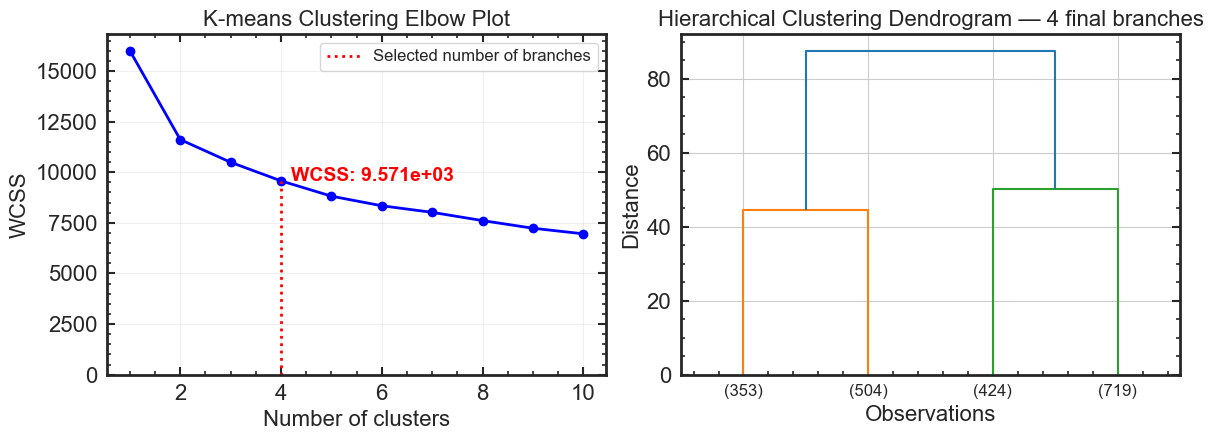

In [15]:
data = read(DEFAULT_FILE if USE_DEFAULTS else dd_file.value)
data_norm = scaler.fit_transform(data)


def elbow(ax, X, branches):
    max_k = min(10, len(X) - 1)
    cluster_range = range(1, max_k + 1)

    wcss = [
        KMeans(
            n_clusters=k,
            n_init=10,
            random_state=RANDOM_STATE,
        ).fit(X).inertia_
        for k in cluster_range
    ]

    ax.plot(cluster_range, wcss, marker="o", ls="-", c="blue", lw=2)
    style_axes(ax, font_size=16, grid=True)

    if branches in cluster_range:
        current_wcss = wcss[branches - 1]

        ax.plot(
            [branches, branches],
            [0, current_wcss],
            c="red",
            ls="dotted",
            lw=2,
            label="Selected number of branches",
        )

        ax.annotate(
            f"WCSS: {current_wcss:.3e}",
            xy=(branches, current_wcss),
            xytext=(branches + 0.2, current_wcss),
            color="red",
            fontweight="bold",
            fontsize=14,
        )

        ax.legend(fontsize=12, loc="upper right")

    ax.set_ylim(bottom=0)
    ax.set_xlabel("Number of clusters", fontsize=16)
    ax.set_ylabel("WCSS", fontsize=16)
    ax.set_title("K-means Clustering Elbow Plot", fontsize=16)


def dendo(branches):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    elbow(ax1, data_norm, branches)

    if len(data_norm) > DENDROGRAM_SAMPLE_LIMIT:
        rng = np.random.default_rng(RANDOM_STATE)
        sample_indices = rng.choice(
            len(data_norm),
            DENDROGRAM_SAMPLE_LIMIT,
            replace=False,
        )
        data_for_linkage = data_norm[sample_indices]

        print(
            f"Dendrogram calculated from a reproducible sample of "
            f"{DENDROGRAM_SAMPLE_LIMIT:,} of {len(data_norm):,} rows."
        )
    else:
        data_for_linkage = data_norm

    hierarchy = linkage(data_for_linkage, method="ward")

    style_axes(ax2, font_size=16)

    dendrogram(
        hierarchy,
        truncate_mode="lastp",
        p=branches,
        show_leaf_counts=True,
        no_labels=False,
        ax=ax2,
    )

    ax2.set_title(
        f"Hierarchical Clustering Dendrogram — {branches} final branches",
        fontsize=16,
    )
    ax2.set_xlabel("Observations", fontsize=16)
    ax2.set_ylabel("Distance", fontsize=16)

    fig.tight_layout()
    plt.show()


if USE_DEFAULTS:
    print("-" * 70)
    print(
        f"Running in DEFAULT MODE: generating charts using "
        f"branches = {DEFAULT_BRANCHES}"
    )
    print("-" * 70)

    dendo(DEFAULT_BRANCHES)

else:
    max_branches = min(15, max(2, len(data) - 1))

    sl_branches = widgets.IntSlider(
        value=min(DEFAULT_BRANCHES, max_branches),
        min=2,
        max=max_branches,
        description="No. of final branches for dendrogram:",
        layout={"width": "60%"},
        style={"description_width": "initial"},
    )

    print("-" * 70)
    print("Interactive mode active.")
    print("-" * 70)

    print("\nUse the slider below to adjust the number of visible dendrogram branches.")
    print(
        "This allows exploration of how the dataset separates into broader or "
        "finer-grained groupings."
    )

    out = widgets.interactive_output(
        dendo,
        {"branches": sl_branches},
    )

    display(widgets.HBox([sl_branches]), out)

### K-Means Clustering

Hierarchical clustering provides an initial view of the dataset structure.
K-means clustering is now used to generate explicit segments.

The workflow below allows dynamic selection of:

- visual comparison dimensions
- number of clusters

K-means is fitted to the full **standardised numeric feature space**.
The selected X and Y features are used only to visualise the resulting clusters.

------------------------------------------------------------
Running in DEFAULT MODE: generating chart using 3 clusters
------------------------------------------------------------


/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_22559/1044587358.py:62: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, alpha=0.3 if grid else 1.0)


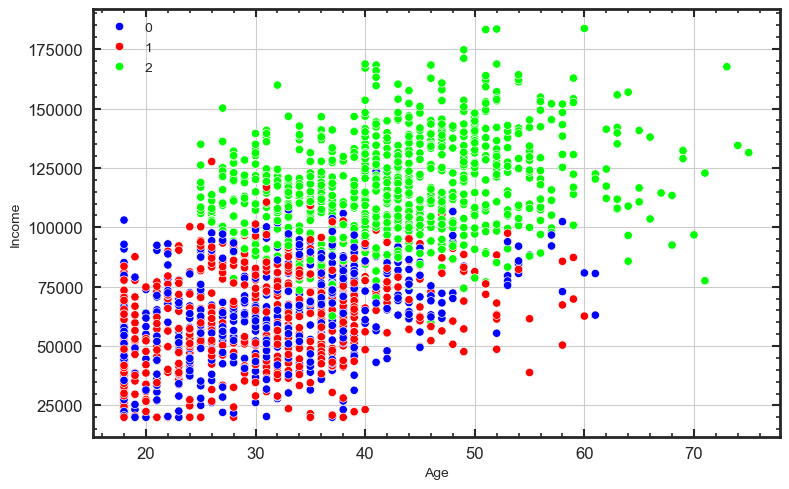

Silhouette score: 0.178


In [16]:
df = read(DEFAULT_FILE if USE_DEFAULTS else dd_file.value)
cols = list(df.columns)

if USE_DEFAULTS:
    initial_clusters = DEFAULT_CLUSTERS
else:
    initial_clusters = sl_branches.value

default_x = "Age" if "Age" in cols else cols[0]
default_y = "Income" if "Income" in cols else cols[1]

dd_para1 = widgets.Dropdown(
    options=cols,
    value=default_x,
    description="x-parameter:",
    layout={"width": "30%"},
    style={"description_width": "initial"},
)

dd_para2 = widgets.Dropdown(
    options=cols,
    value=default_y,
    description="y-parameter:",
    layout={"width": "30%"},
    style={"description_width": "initial"},
)

max_clusters = min(10, len(df) - 1)

sl_clus = widgets.IntSlider(
    value=min(initial_clusters, max_clusters),
    min=2,
    max=max_clusters,
    description="No. of clusters:",
    layout={"width": "80%"},
    style={"description_width": "initial"},
)


def clus_plot(data, para1, para2, hue_column):
    fig, ax = plt.subplots(figsize=(8, 5))
    style_axes(ax, font_size=12)

    labels = list(pd.unique(data[hue_column].dropna()))
    hue_colors = {
        label: PALETTE[i % len(PALETTE)]
        for i, label in enumerate(labels)
    }

    sns.scatterplot(
        x=para1,
        y=para2,
        data=data,
        hue=hue_column,
        palette=hue_colors,
        ax=ax,
    )

    ax.legend(fontsize=10, loc="upper left", frameon=False)
    ax.set_xlabel(para1)
    ax.set_ylabel(para2)

    fig.tight_layout()
    plt.show()


def cluster_data(data, para1, para2, n_clusters):
    X = scaler.fit_transform(data)

    model = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(X)

    clustered = data.copy()
    clustered["SKM"] = labels

    global df_kmeans_temp, current_clus_count, current_kmeans_model
    df_kmeans_temp = clustered
    current_clus_count = n_clusters
    current_kmeans_model = model

    clus_plot(clustered, para1, para2, "SKM")

    if n_clusters < len(data):
        score = silhouette_score(X, labels)
        print(f"Silhouette score: {score:.3f}")

    return clustered


if USE_DEFAULTS:
    print("-" * 60)
    print(
        f"Running in DEFAULT MODE: generating chart using "
        f"{DEFAULT_CLUSTERS} clusters"
    )
    print("-" * 60)

    cluster_data(
        data=df,
        para1=default_x,
        para2=default_y,
        n_clusters=DEFAULT_CLUSTERS,
    )

else:
    wrapped_cluster = partial(cluster_data, data=df)

    out = widgets.interactive_output(
        wrapped_cluster,
        {
            "para1": dd_para1,
            "para2": dd_para2,
            "n_clusters": sl_clus,
        },
    )

    spacer = widgets.Box(layout=widgets.Layout(width="50px"))

    controls = widgets.HBox([
        dd_para1,
        spacer,
        dd_para2,
        spacer,
        sl_clus,
    ])

    print("-" * 85)
    print("- Select axes that provide a useful visual projection.")
    print("- Adjust the cluster count to explore different segmentation granularities.")
    print(
        "  Smaller values reveal broader population structure; larger values "
        "create finer segmentation."
    )
    print("-" * 85)

    display(controls, out)

### Cluster Interpretation

Unsupervised learning identifies statistical groupings, but interpretation is
required to translate these into meaningful profiles.

The cluster profile table summarises the mean numeric feature values, number of
observations and proportion of the dataset in each cluster.

For the default customer dataset, descriptive labels are provided for the
four-cluster example. In interactive mode, generic labels are used and can be
edited directly in the mapping dictionary.

Generic cluster labels are being used. Edit `dynamic_mapping` in this cell if you want domain-specific names -- base any name on the actual per-cluster profile below (e.g. income, education, occupation), not on demographic splits like sex or marital status alone, which are not evidence of a meaningful group difference.


SKM,Cluster 0,Cluster 1,Cluster 2
ID,1.000010e+08,1.000010e+08,1.000010e+08
Sex,1.000000e+00,0.000000e+00,4.928571e-01
Marital status,2.990991e-01,3.223140e-01,4.940476e-01
Age,3.087387e+01,3.037686e+01,4.275952e+01
Education,5.405405e-01,5.752066e-01,2.186905e+00
Income,6.145979e+04,6.063849e+04,1.173666e+05
Occupation,2.936937e-01,2.876033e-01,1.285714e+00
Settlement size,9.927928e-01,9.504132e-01,1.032143e+00
N Obs,5.550000e+02,6.050000e+02,8.400000e+02
Prop Obs,2.775000e-01,3.025000e-01,4.200000e-01


/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_22559/1044587358.py:62: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, alpha=0.3 if grid else 1.0)


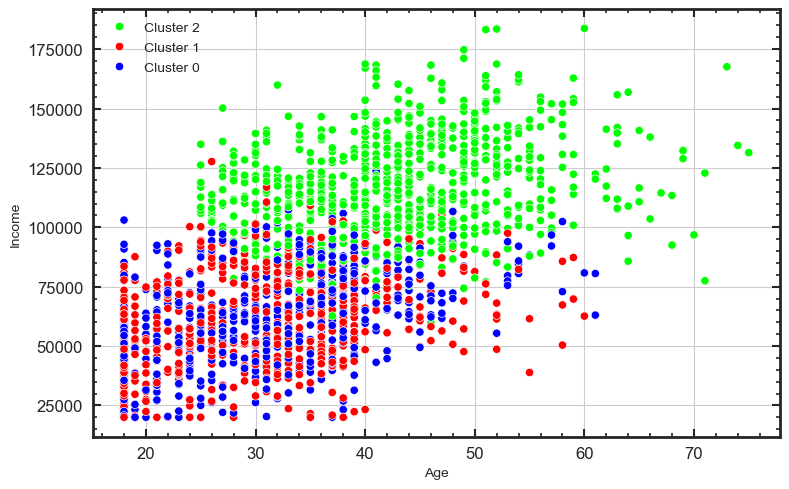

In [17]:
n_clusters = current_clus_count

dynamic_mapping = {
    cluster: f"Cluster {cluster}"
    for cluster in range(n_clusters)
}

print(
    "Generic cluster labels are being used. Edit `dynamic_mapping` "
    "in this cell if you want domain-specific names -- base any name on "
    "the actual per-cluster profile below (e.g. income, education, "
    "occupation), not on demographic splits like sex or marital status "
    "alone, which are not evidence of a meaningful group difference."
)

df_kmeans_temp["Cluster_Label"] = (
    df_kmeans_temp["SKM"].map(dynamic_mapping)
)

profile = df_kmeans_temp.groupby("SKM").mean(numeric_only=True)
profile["N Obs"] = df_kmeans_temp.groupby("SKM").size()
profile["Prop Obs"] = profile["N Obs"] / len(df_kmeans_temp)

profile = profile.rename(index=dynamic_mapping)

display(profile.transpose())

clus_plot(
    df_kmeans_temp,
    default_x if USE_DEFAULTS else dd_para1.value,
    default_y if USE_DEFAULTS else dd_para2.value,
    "Cluster_Label",
)

### Principal Component Analysis

The original dataset contains multiple correlated variables, making direct
visualisation difficult.

*Principal Component Analysis* (PCA) reduces the dimensionality of the dataset
while preserving as much variance as possible.

This enables:

- lower-dimensional visualisation
- noise reduction
- improved cluster separation analysis

-------------------------
Running in DEFAULT MODE
-------------------------
---------------------------------------------
Selected Threshold: 80% Explained Variance
Dynamically Using: 5 Principal Components
---------------------------------------------


/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_22559/1044587358.py:62: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, alpha=0.3 if grid else 1.0)


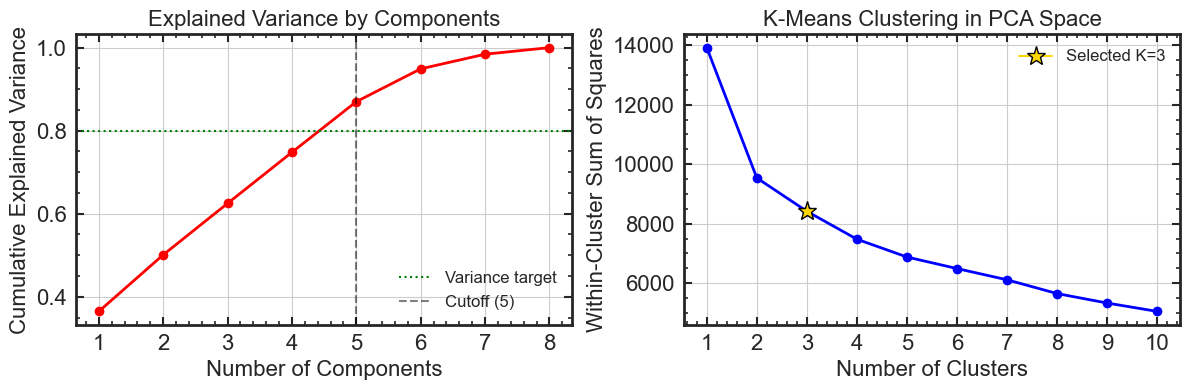

In [18]:
data = df.copy()
data.columns = data.columns.astype(str)

data_norm = scaler.fit_transform(data)

max_components = min(data.shape[0], data.shape[1])

dd_variance = widgets.Dropdown(
    options=[
        ("Manual override", "manual"),
        ("70%", 0.70),
        ("75%", 0.75),
        ("80%", 0.80),
        ("85%", 0.85),
        ("90%", 0.90),
        ("95%", 0.95),
        ("99%", 0.99),
    ],
    value=DEFAULT_VARIANCE,
    description="Target variance threshold:",
    layout={"width": "35%"},
    style={"description_width": "initial"},
)

dd_components = widgets.Dropdown(
    options=[
        (f"{i} Component" if i == 1 else f"{i} Components", i)
        for i in range(1, max_components + 1)
    ],
    value=min(3, max_components),
    description="Manual component count:",
    layout={"width": "45%"},
    style={"description_width": "initial"},
)


def run_variance_pipeline(target_variance, manual_comps):
    pca_full = PCA(n_components=max_components)
    pca_full.fit(data_norm)

    cumulative_variance = np.cumsum(
        pca_full.explained_variance_ratio_
    )

    if target_variance == "manual":
        n_retained = int(manual_comps)
        captured_variance = cumulative_variance[n_retained - 1]

        print("-" * 55)
        print("Mode: MANUAL OVERRIDE ACTIVE")
        print(f"Using: {n_retained} Principal Components")
        print(f"Total Variance Captured: {captured_variance * 100:.2f}%")
        print("-" * 55)

    else:
        n_retained = int(
            np.argmax(cumulative_variance >= target_variance) + 1
        )

        print("-" * 45)
        print(
            f"Selected Threshold: "
            f"{target_variance * 100:.0f}% Explained Variance"
        )
        print(f"Dynamically Using: {n_retained} Principal Components")
        print("-" * 45)

    pca = PCA(n_components=n_retained)
    scores = pca.fit_transform(data_norm)

    loadings = pd.DataFrame(
        pca.components_,
        columns=data.columns,
        index=[
            f"Component {i + 1}"
            for i in range(n_retained)
        ],
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    style_axes(ax1, font_size=16)
    style_axes(ax2, font_size=16)

    x_components = range(
        1,
        len(pca_full.explained_variance_ratio_) + 1,
    )

    ax1.plot(
        x_components,
        cumulative_variance,
        marker="o",
        ls="-",
        c="red",
        lw=2,
    )

    if target_variance == "manual":
        ax1.axhline(
            y=cumulative_variance[n_retained - 1],
            color="orange",
            linestyle=":",
            label="Manual selection",
        )
    else:
        ax1.axhline(
            y=target_variance,
            color="green",
            linestyle=":",
            label="Variance target",
        )

    ax1.axvline(
        x=n_retained,
        color="black",
        linestyle="--",
        alpha=0.5,
        label=f"Cutoff ({n_retained})",
    )

    ax1.set_title("Explained Variance by Components", fontsize=16)
    ax1.set_xlabel("Number of Components", fontsize=16)
    ax1.set_ylabel("Cumulative Explained Variance", fontsize=16)

    if max_components <= 20:
        ax1.set_xticks(list(x_components))

    ax1.legend(
        loc="lower right",
        fontsize=12,
        frameon=False,
    )

    max_k = min(10, len(scores) - 1)
    cluster_range = range(1, max_k + 1)

    wcss = []

    for k in cluster_range:
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=RANDOM_STATE,
        )
        model.fit(scores)
        wcss.append(model.inertia_)

    ax2.plot(
        cluster_range,
        wcss,
        marker="o",
        ls="-",
        c="blue",
        lw=2,
    )

    ax2.set_title("K-Means Clustering in PCA Space", fontsize=16)
    ax2.set_xlabel("Number of Clusters", fontsize=16)
    ax2.set_ylabel("Within-Cluster Sum of Squares", fontsize=16)
    ax2.set_xticks(list(cluster_range))

    selected_k = current_clus_count

    if selected_k in cluster_range:
        ax2.plot(
            selected_k,
            wcss[selected_k - 1],
            marker="*",
            c="gold",
            markersize=14,
            markeredgecolor="black",
            label=f"Selected K={selected_k}",
        )

        ax2.legend(
            fontsize=12,
            frameon=False,
        )

    fig.tight_layout()
    plt.show()

    global pca_scores, current_components_count, global_df_pca_comp
    pca_scores = scores
    current_components_count = n_retained
    global_df_pca_comp = loadings


if USE_DEFAULTS:
    print("-" * 25)
    print("Running in DEFAULT MODE")
    print("-" * 25)

    run_variance_pipeline(DEFAULT_VARIANCE, min(4, max_components))

else:
    print("\nThe controls below allow either:")
    print(
        " - automatic component selection based on a target "
        "explained variance threshold"
    )
    print(
        " - manual override of the number of retained components"
    )

    out = widgets.interactive_output(
        run_variance_pipeline,
        {
            "target_variance": dd_variance,
            "manual_comps": dd_components,
        },
    )

    spacer = widgets.Box(
        layout=widgets.Layout(width="30px")
    )

    display(
        widgets.HBox([
            dd_variance,
            spacer,
            dd_components,
        ]),
        out,
    )

### Interpretation

The explained variance curve shows how much dataset information is retained as
additional principal components are included.

The elbow curve complements this by evaluating clustering compactness in PCA
space under different cluster counts.

Together, these diagnostics help balance:

- dimensionality reduction
- cluster interpretability
- segmentation stability

### PCA-Based Cluster Projection

The final visualisation projects the **existing K-means clusters** into
lower-dimensional PCA space.

K-means itself remains fitted in the full standardised feature space. PCA is
used here only for visualisation, so the final projection does not silently
replace the original segmentation with a second clustering model.

Cluster labels used in PCA projection:
   Cluster 0 -> 'Cluster 0'
   Cluster 1 -> 'Cluster 1'
   Cluster 2 -> 'Cluster 2'
-------------------------------------------------------------------------------------
Running in DEFAULT MODE — projecting the existing clusters into two PCA dimensions.
-------------------------------------------------------------------------------------


/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_22559/1044587358.py:62: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, alpha=0.3 if grid else 1.0)


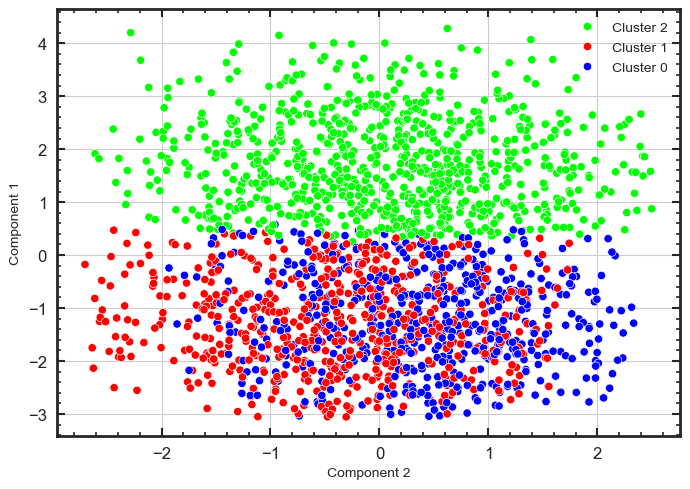

In [19]:
chosen_k = current_clus_count
chosen_components = current_components_count

component_names = [
    f"Component {i + 1}"
    for i in range(chosen_components)
]

df_scores = pd.DataFrame(
    pca_scores,
    columns=component_names,
    index=df.index,
)

df_PCA = pd.concat(
    [
        data.reset_index(drop=True),
        df_scores.reset_index(drop=True),
    ],
    axis=1,
)

# Preserve the K-means clustering fitted in the full standardised feature space.
df_PCA["SKM"] = df_kmeans_temp["SKM"].to_numpy()
df_PCA["Labels"] = df_PCA["SKM"].map(dynamic_mapping)

profile_pca = df_PCA.groupby("SKM").mean(numeric_only=True)
profile_pca["N Obs"] = df_PCA.groupby("SKM").size()
profile_pca["Prop Obs"] = profile_pca["N Obs"] / len(df_PCA)

profile_pca = profile_pca.rename(index=dynamic_mapping)

print("Cluster labels used in PCA projection:")
for cluster in range(chosen_k):
    print(
        f"   Cluster {cluster} -> "
        f"'{dynamic_mapping.get(cluster, f'Cluster {cluster}')}'"
    )

df_PCA.groupby("SKM").head(2)


dd_comp1 = widgets.Dropdown(
    options=component_names,
    value=component_names[0],
    description="X Axis Component:",
    layout={"width": "45%"},
    style={"description_width": "initial"},
)

dd_comp2 = widgets.Dropdown(
    options=component_names,
    value=(
        component_names[1]
        if len(component_names) > 1
        else component_names[0]
    ),
    description="Y Axis Component:",
    layout={"width": "45%"},
    style={"description_width": "initial"},
)


def pca_scatter(x_component, y_component):
    fig, ax = plt.subplots(figsize=(7, 5))
    style_axes(ax, font_size=12)

    labels = list(pd.unique(df_PCA["Labels"]))
    colours = {
        label: PALETTE[i % len(PALETTE)]
        for i, label in enumerate(labels)
    }

    sns.scatterplot(
        x=x_component,
        y=y_component,
        data=df_PCA,
        hue="Labels",
        palette=colours,
        ax=ax,
    )

    ax.legend(fontsize=10, frameon=False)
    ax.set_xlabel(x_component)
    ax.set_ylabel(y_component)

    fig.tight_layout()
    plt.show()


if len(component_names) < 2:
    print(
        "Only one PCA component was retained; "
        "a 2D PCA projection is not available."
    )

elif USE_DEFAULTS:
    print("-" * 85)
    print(
        "Running in DEFAULT MODE — projecting the existing "
        "clusters into two PCA dimensions."
    )
    print("-" * 85)

    x_component = (
        "Component 2"
        if "Component 2" in component_names
        else component_names[0]
    )
    y_component = component_names[0]

    pca_scatter(x_component, y_component)

else:
    out = widgets.interactive_output(
        pca_scatter,
        {
            "x_component": dd_comp1,
            "y_component": dd_comp2,
        },
    )

    controls = widgets.HBox([
        dd_comp1,
        widgets.Box(
            layout=widgets.Layout(width="30px")
        ),
        dd_comp2,
    ])

    print("\nCustom Component Visualisation Panel:")
    display(controls, out)